# 10 · Classic time-series analyses

Airline passengers, Nile flow and Mauna Loa CO₂ distinguish serial dependence, trend and seasonality.
Restart Kernel and Run All builds each time series and ARIMAX model from the frozen observations,
runs the saved Bayesian configuration, and plots the newly computed results.
API reference: BestFit Verification `TimeSeriesAnalysis/ARIMAXAnalysisTests.cs` and
`Datasets/TimeSeriesData/RealTimeSeriesData.cs`; those files are construction guides, not substitute data.

In [2]:
from pathlib import Path
import sys
from time import perf_counter
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import numpy as np
from IPython.display import display
from bestfit_examples.runtime import load_bestfit
from bestfit_examples.raw import load_raw
from bestfit_examples.fresh import plot_context, plots, show, record_run
print(load_bestfit())
from System import Array, DateTime, Double
from System.Collections.Generic import List
from Numerics.Data import TimeInterval, TimeSeries, SeriesOrdinate
from Numerics.Distributions import Uniform
from RMC.BestFit.Models import ARIMAX, Transform
from RMC.BestFit.Analyses import ARIMAXAnalysis
from RMC.BestFit.Estimation import BayesianAnalysis

{'schemaVersion': 1, 'sourceCommit': 'db5807d6e3a85606797cda79542f2d51a80a57a6', 'numericsVersion': '2.2.0.0', 'bestFitVersion': '2.0.0.0', 'targetFramework': '.NETCoreApp,Version=v10.0', 'fileHashes': {'RMC.BestFit.dll': '8714d7e4e9d738e99e45c36d5581ce759e8fd535361b7a141d9647a9a5eac8dd', 'Numerics.dll': '364d2296a6024643a8bf0f60d1eaa8f5be5511563dea0b5d572074e45c27ea48'}}


## Frozen observed series

These are the project observations, with their original dates, intervals and values. Constructing
`TimeSeries` here makes the input and index treatment visible. Airline has 144 monthly values;
Nile has 100 annual values; Mauna Loa is monthly. Nothing is downloaded or simulated.

In [3]:
raw = load_raw("classic-time-series-examples")
series = {}
for name in ("Airline Passengers", "Nile River Flows", "Mauna Loa CO2"):
    source = raw["series"][name]
    observed = TimeSeries(getattr(TimeInterval, source["attributes"]["TimeInterval"]))
    for row in source["records"]:
        observed.Add(SeriesOrdinate[DateTime, Double](DateTime.Parse(row["Index"]), float(row["Value"])))
    series[name] = observed
display(pd.DataFrame([{"Series": name, "Observations": ts.Count,
                       "First source date": str(ts[0].Index.ToString("yyyy-MM-dd")),
                       "Last source date": str(ts[ts.Count-1].Index.ToString("yyyy-MM-dd")),
                       "Interval": str(ts.TimeInterval)}
                      for name, ts in series.items()]))
print(raw["source"])

,Series,Observations,First source date,Last source date,Interval
0,Airline Passengers,144,1949-01-01,1960-12-01,OneMonth
1,Nile River Flows,100,1897-01-01,1996-01-01,OneYear
2,Mauna Loa CO2,790,1958-03-01,2023-12-01,OneMonth


{'bytes': 7143424, 'relative_path': 'examples/7-time-series-analysis/2-classic-time-series-examples/classic-time-series-examples.bestfit', 'repository_commit': '3fa55a0f75bbd583e2fb7fce42180faa376f007c', 'sha256': '9eca00ee4cf0f1b06b79c0dd1257ceac9f444192b9ce50a3272ecf6d9852cfeb'}


## Preserve the three saved model designs

Airline is ARIMA(1,1,1), Nile ARIMA(1,1,0), and Mauna Loa is a quadratic trend plus Fourier
seasonality with no ARMA terms. Training lengths and the zero future horizon are the project settings.
Airline's last 24 and Nile's last 20 observations are held out from fitting; they are not future dates.
The tuples retain the original bounds and uniform priors. They are assigned after structural
options because those options rebuild the parameter list. DEMCzs initializes from these priors;
fitted parameter values are obtained only after running the new analysis.

In [4]:
cases = {
    "Airline Passengers - TSA": {
        "series": "Airline Passengers", "orders": (1, 1, 1), "season": False,
        "trend": getattr(ARIMAX.Trend, "None"), "default_training": False, "training": 120,
        "chains": 8, "thin": 40, "initial": 400, "jump": 0.8414570696119914,
        "advanced_defaults": True,
        "parameters": [(.1, 100), (-2, 2), (-2, 2), (1.11022302462516e-16, 1000)]},
    "Nile River Flows - TSA": {
        "series": "Nile River Flows", "orders": (1, 1, 0), "season": False,
        "trend": getattr(ARIMAX.Trend, "None"), "default_training": False, "training": 80,
        "chains": 6, "thin": 30, "initial": 300, "jump": .25,
        "advanced_defaults": False,
        "parameters": [(-100, -.1), (-2, 2), (1.11022302462516e-16, 10000)]},
    "Mauna Loa - CO2": {
        "series": "Mauna Loa CO2", "orders": (0, 0, 0), "season": True,
        "trend": ARIMAX.Trend.Quadratic, "default_training": True, "training": 632,
        "chains": 12, "thin": 60, "initial": 600, "jump": .68704682033565467,
        "advanced_defaults": True,
        "parameters": [(10, 10000), (-1, 1), (-.001, .001), (-2497.5, 2497.5),
                       (-2497.5, 2497.5), (1.11022302462516e-16, 1000)]},
}
models = {}
for name, settings in cases.items():
    model = ARIMAX(series[settings["series"]])
    model.TransformType = getattr(Transform, "None")
    model.IncludeIntercept = True
    model.IncludeSeasonality = settings["season"]
    model.TrendType = settings["trend"]
    model.AROrderP, model.DiffOrderD, model.MAOrderQ = settings["orders"]
    model.XOrderB = 0
    model.CovariateExtension = ARIMAX.CovariateExtensionMethod.BlockBootstrap
    model.UseDefaultFlatPriors = True
    model.UseJeffreysRuleForScale = True
    model.UseDefaultTrainingSteps = settings["default_training"]
    if not settings["default_training"]:
        model.TrainingTimeSteps = settings["training"]
    assert model.TrainingTimeSteps == settings["training"]
    assert model.Parameters.Count == len(settings["parameters"])
    for parameter, (lower, upper) in zip(model.Parameters, settings["parameters"]):
        parameter.LowerBound = lower
        parameter.UpperBound = upper
        parameter.PriorDistribution = Uniform(lower, upper)
        parameter.IsPositive = parameter.Name.startswith("Scale")
        parameter.IsFixed = False
    models[name] = model
display(pd.DataFrame([{"Analysis": n, "Orders": c["orders"], "Seasonality": c["season"],
                       "Trend": str(c["trend"]), "Training": m.TrainingTimeSteps,
                       "Holdout": m.TimeSeries.Count - m.TrainingTimeSteps}
                      for n, c in cases.items() for m in [models[n]]]))

,Analysis,Orders,Seasonality,Trend,Training,Holdout
0,Airline Passengers - TSA,"(1, 1, 1)",False,None,120,24
1,Nile River Flows - TSA,"(1, 1, 0)",False,None,80,20
2,Mauna Loa - CO2,"(0, 0, 0)",True,Quadratic,632,158


## Run the saved Bayesian analyses

`ARIMAXAnalysis.ForecastingTimeSteps` adds dates beyond the observed series. It is zero here.
All three cases retain DEMCzs, 3,500 iterations, 1,750 warmup, seed 12345, 90% intervals and
the remaining saved sampler options. A completed run is not a convergence verdict.

In [5]:
analyses, timings = {}, {}
for name, settings in cases.items():
    analysis = ARIMAXAnalysis(models[name])
    analysis.ForecastingTimeSteps = 0
    bayes = analysis.BayesianAnalysis
    bayes.Type = BayesianAnalysis.SamplerType.DEMCzs
    bayes.UseSimulationDefaults = True
    bayes.UseAdvancedSimulationDefaults = settings["advanced_defaults"]
    bayes.NumberOfChains = settings["chains"]
    bayes.ThinningInterval = settings["thin"]
    bayes.WarmupIterations = 1750
    bayes.Iterations = 3500
    bayes.PRNGSeed = 12345
    bayes.InitialIterations = settings["initial"]
    bayes.Jump = settings["jump"]
    bayes.JumpThreshold = .1
    bayes.SnookerThreshold = .1
    bayes.Noise = 1e-12
    bayes.Scale = 5.6644
    bayes.Beta = .05
    bayes.MaxTreeDepth = 10
    bayes.CredibleIntervalWidth = .9
    bayes.OutputLength = 10000
    bayes.PointEstimator = BayesianAnalysis.PointEstimateType.PosteriorMean
    started = perf_counter()
    analysis.RunAsync(None).GetAwaiter().GetResult()
    timings[name] = perf_counter() - started
    analyses[name] = analysis
    record_run(name, analysis, timings[name], raw=raw, model=models[name])

Airline Passengers - TSA: completed in 2.64 s. Execution alone does not establish convergence or scientific acceptance.


Nile River Flows - TSA: completed in 0.84 s. Execution alone does not establish convergence or scientific acceptance.


Mauna Loa - CO2: completed in 18.29 s. Execution alone does not establish convergence or scientific acceptance.


## Read fit and convergence from these runs

Fit scores refer to different responses and are shown per case, not ranked across cases.
Check the parameter diagnostics before interpreting a predictive interval. In the prior full-settings
audit Airline had maximum R-hat about 1.26 and minimum ESS about 52; the values below report this run.

In [6]:
summary, diagnostics = [], []
for name, analysis in analyses.items():
    result = analysis.AnalysisResults
    summary.append({"Analysis": name, "DIC": float(result.DIC), "AIC": float(result.AIC),
                    "RMSE": float(result.RMSE), "Seconds": timings[name]})
    for parameter, estimate in zip(models[name].Parameters, analysis.BayesianAnalysis.Results.ParameterResults):
        stats = estimate.SummaryStatistics
        diagnostics.append({"Analysis": name, "Parameter": str(parameter.Name),
                            "R-hat": float(stats.Rhat), "ESS": float(stats.ESS),
                            "Posterior mean": float(stats.Mean)})
display(pd.DataFrame(summary))
diagnostics = pd.DataFrame(diagnostics)
display(diagnostics)
airline_diag = diagnostics[diagnostics.Analysis == "Airline Passengers - TSA"]
print("Airline maximum R-hat:", airline_diag["R-hat"].max(),
      "minimum ESS:", airline_diag.ESS.min())

,Analysis,DIC,AIC,RMSE,Seconds
0,Airline Passengers - TSA,1115.279455,1100.857869,26.649927,2.641554
1,Nile River Flows - TSA,1016.318892,1016.998406,156.318431,0.842692
2,Mauna Loa - CO2,1720.183893,1720.316210,0.934708,18.294480


,Analysis,Parameter,R-hat,ESS,Posterior mean
0,Airline Passengers - TSA,Intercept (μ),1.081351,1469.444719,3.364345
1,Airline Passengers - TSA,AR (φ₁),1.158785,126.805847,-0.368327
2,Airline Passengers - TSA,MA (θ₁),1.262019,51.560858,0.728826
3,Airline Passengers - TSA,Scale (σ),1.161593,217.674357,27.131068
4,Nile River Flows - TSA,Intercept (μ),1.000249,6606.718977,-11.958041
5,Nile River Flows - TSA,AR (φ₁),1.000412,7143.404736,-0.397363
6,Nile River Flows - TSA,Scale (σ),0.999880,6166.198331,161.576690
7,Mauna Loa - CO2,Intercept (μ),1.000310,9984.842408,314.161766
8,Mauna Loa - CO2,Trend (γ₁),1.000278,10202.873438,0.068459
9,Mauna Loa - CO2,Trend (γ₂),1.000241,9604.088680,0.000083


Airline maximum R-hat: 1.262018700253505 minimum ESS: 51.56085809824184


## Check the fitted model's residuals independently

For Airline and Nile, first differences follow an AR(1) model (plus MA(1) for Airline),
with the initial conditional residual zero. For Mauna Loa, the mean is a quadratic trend
plus one sine/cosine seasonal pair. The formulas below use raw training values and the newly
estimated parameters to check BestFit's residuals and Gaussian data log-likelihood.
A 1e-8 absolute tolerance covers double-precision arithmetic and summation; this checks model
calculations, not posterior correctness or forecast adequacy.

In [7]:
arithmetic_checks = []
for name, model in models.items():
    n = model.TrainingTimeSteps
    y = np.array([float(row["Value"]) for row in raw["series"][cases[name]["series"]]["records"][:n]])
    p = np.array([float(parameter.Value) for parameter in model.Parameters])
    if name == "Mauna Loa - CO2":
        t = np.arange(n)
        mean = p[0] + p[1]*t + p[2]*t*t + p[3]*np.sin(2*np.pi*t/12) + p[4]*np.cos(2*np.pi*t/12)
        expected_residuals = y - mean
        evaluated_errors = expected_residuals
    else:
        differences = np.diff(y)
        expected_residuals = np.zeros(len(differences))
        mu, phi = p[:2]
        theta = p[2] if name == "Airline Passengers - TSA" else 0.0
        for t in range(1, len(differences)):
            expected_residuals[t] = differences[t] - mu - phi*(differences[t-1] - mu) - theta*expected_residuals[t-1]
        evaluated_errors = expected_residuals[1:]
    sigma = p[-1]
    expected_log_likelihood = float(np.sum(-np.log(sigma*np.sqrt(2*np.pi)) - .5*(evaluated_errors/sigma)**2))
    parameters = Array[Double](p.tolist())
    np.testing.assert_allclose(list(model.Residuals(parameters)), expected_residuals, rtol=1e-12, atol=1e-8)
    np.testing.assert_allclose(model.DataLogLikelihood(parameters), expected_log_likelihood, rtol=1e-12, atol=1e-8)
    arithmetic_checks.append({"Case": name, "Independent Gaussian data log-likelihood": expected_log_likelihood,
                              "Conditional terms": len(evaluated_errors)})
display(pd.DataFrame(arithmetic_checks))

,Case,Independent Gaussian data log-likelihood,Conditional terms
0,Airline Passengers - TSA,-555.805723,118
1,Nile River Flows - TSA,-505.744526,78
2,Mauna Loa - CO2,-854.112939,632


## Plot the newly computed predictions and residuals

The bands distinguish the training segment from the observed holdout segment. The frozen Nile
project records 1897–1996, while its reference CSV dates the same 100 values to 1871–1970.
The 26-year correction is for display only; the model and source observations above retain project dates.
Residual horizontal coordinates are dates. Physical forecast credibility requires separate scrutiny.

Airline Passengers - TSA


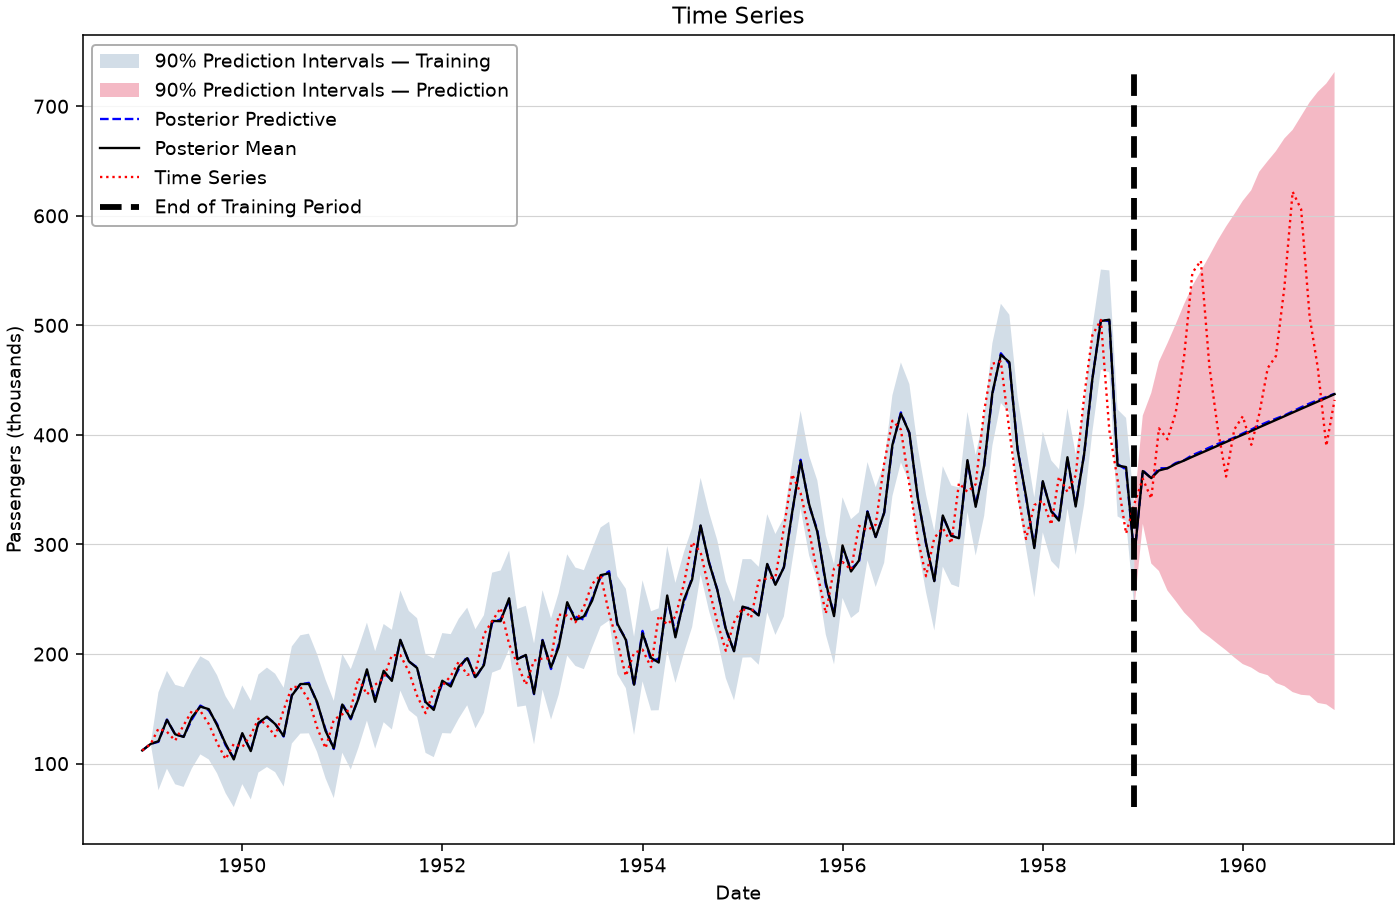

Nile River Flows - TSA


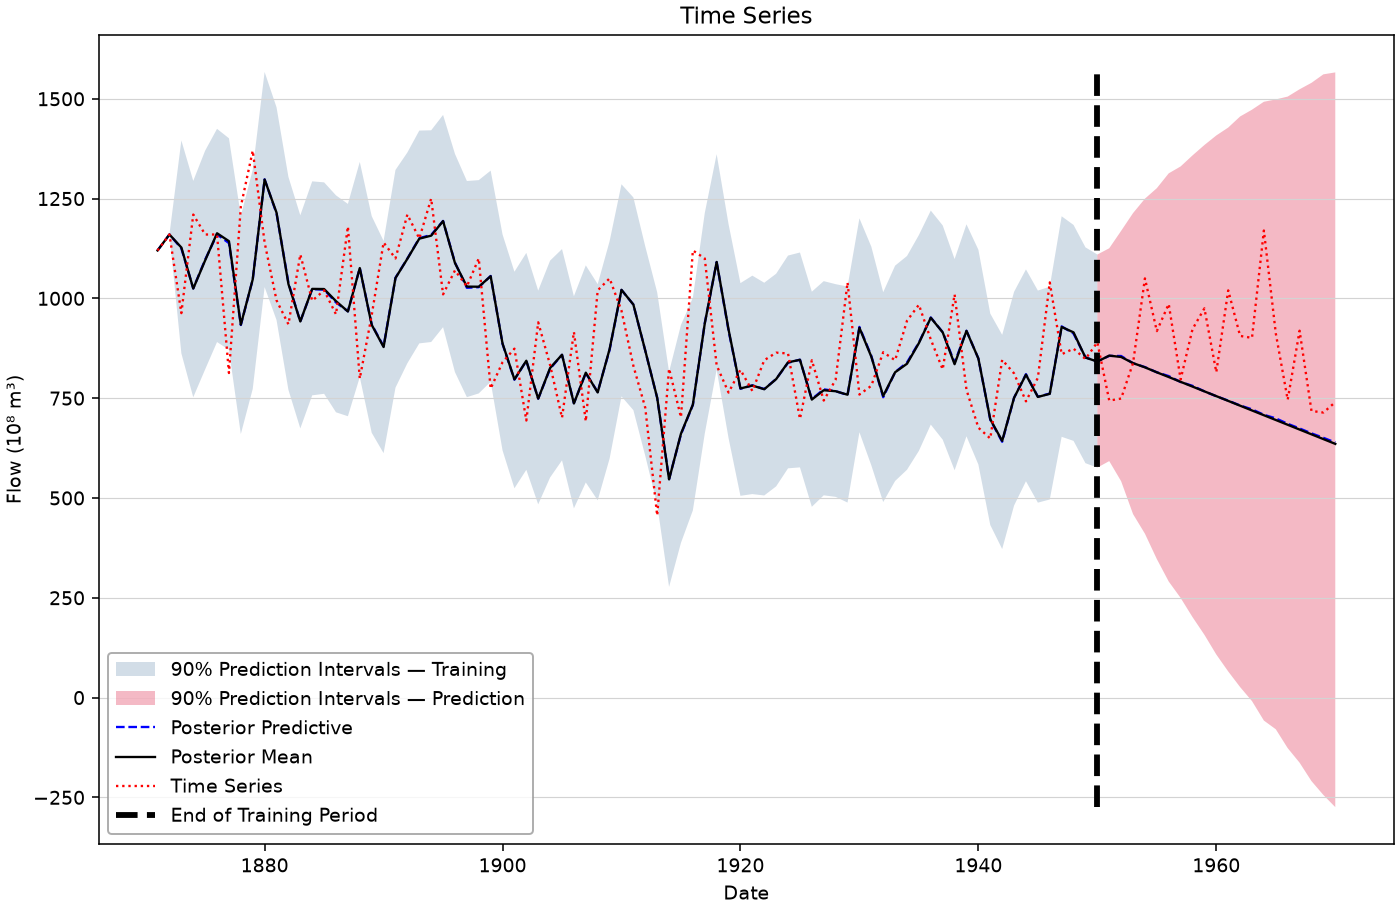

Mauna Loa - CO2


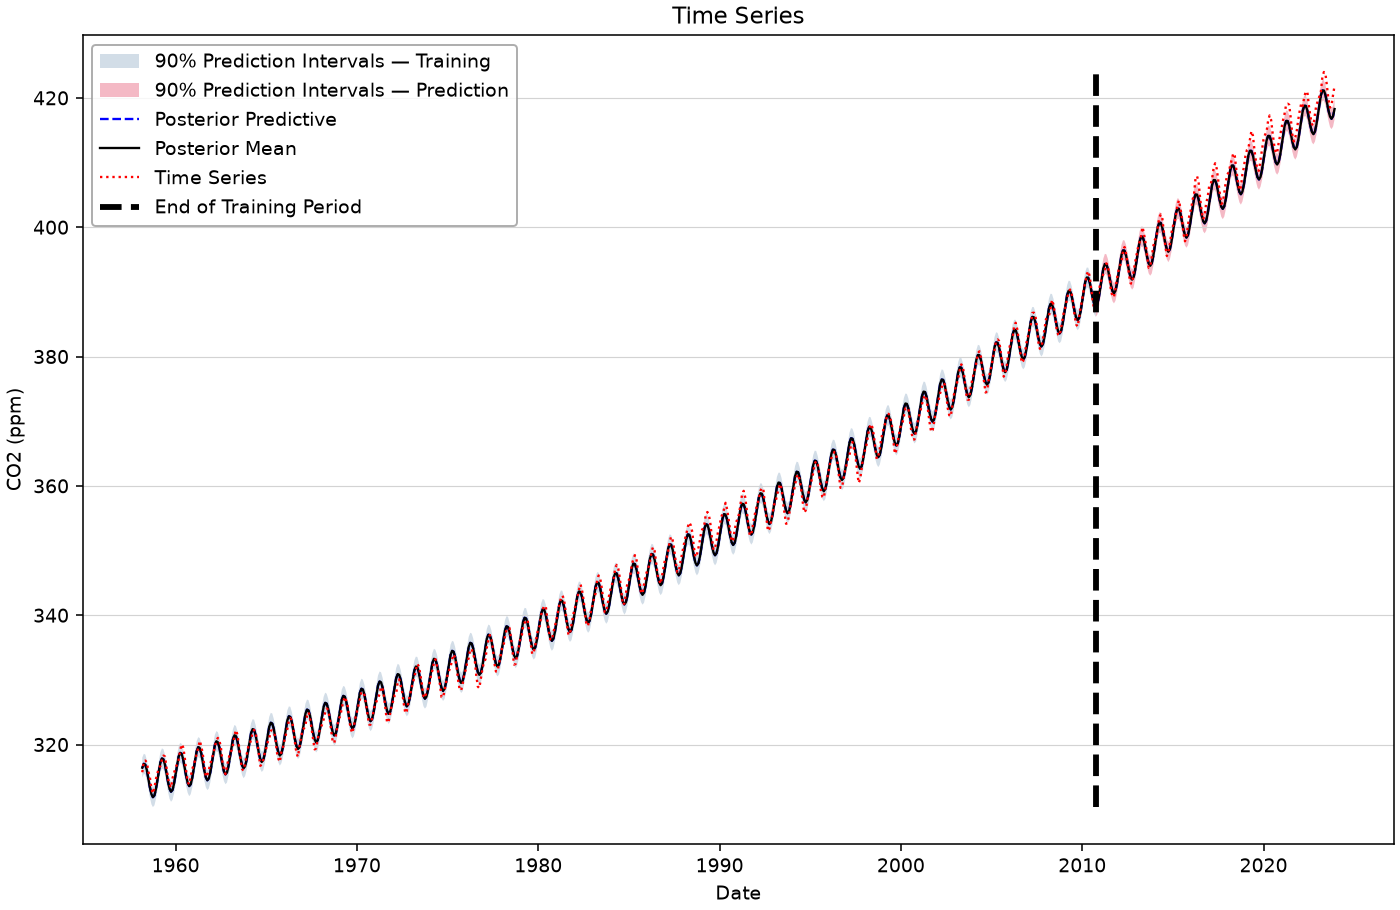

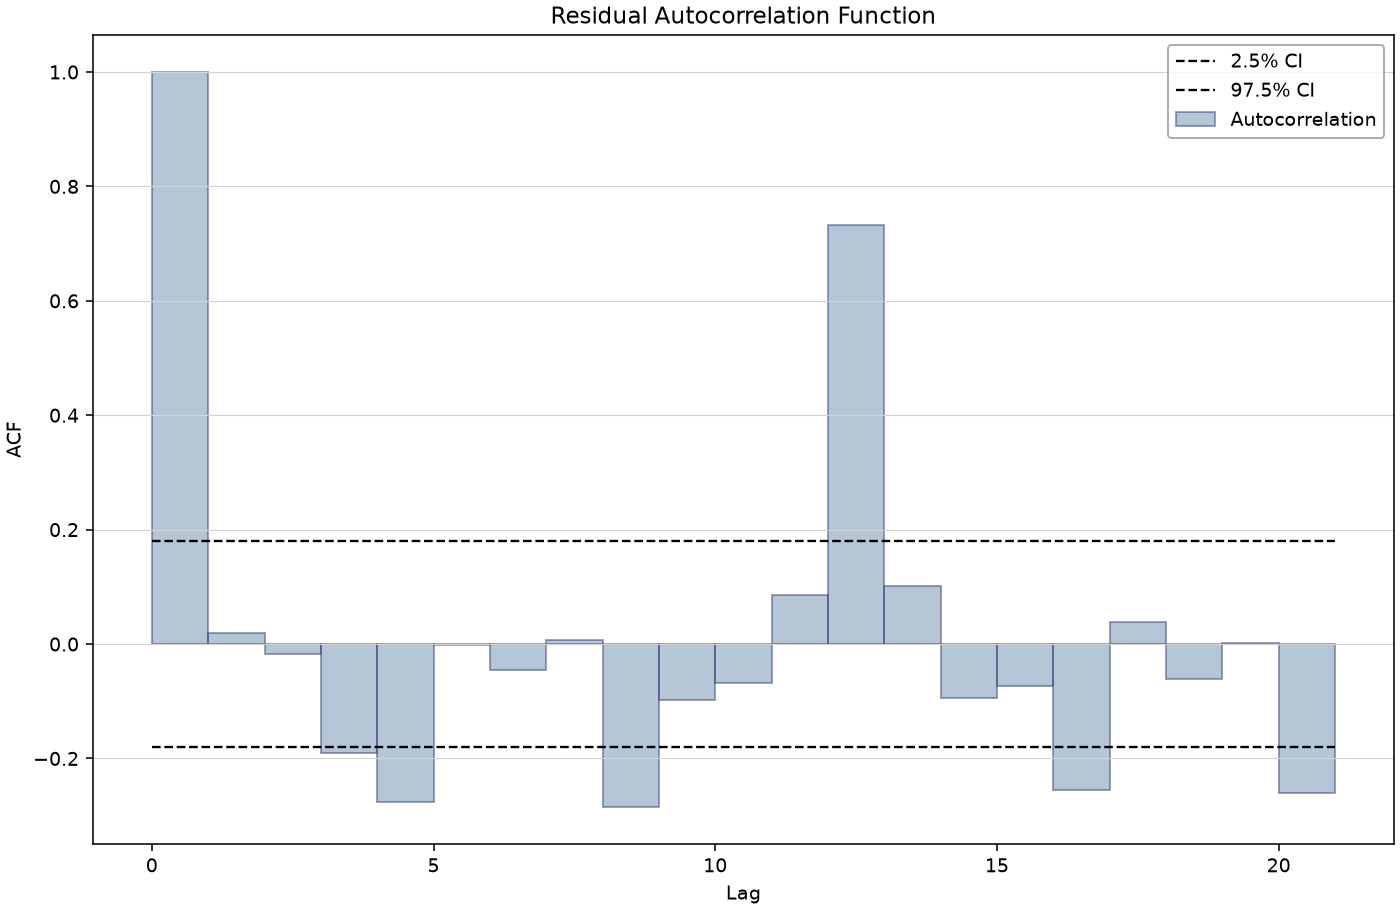

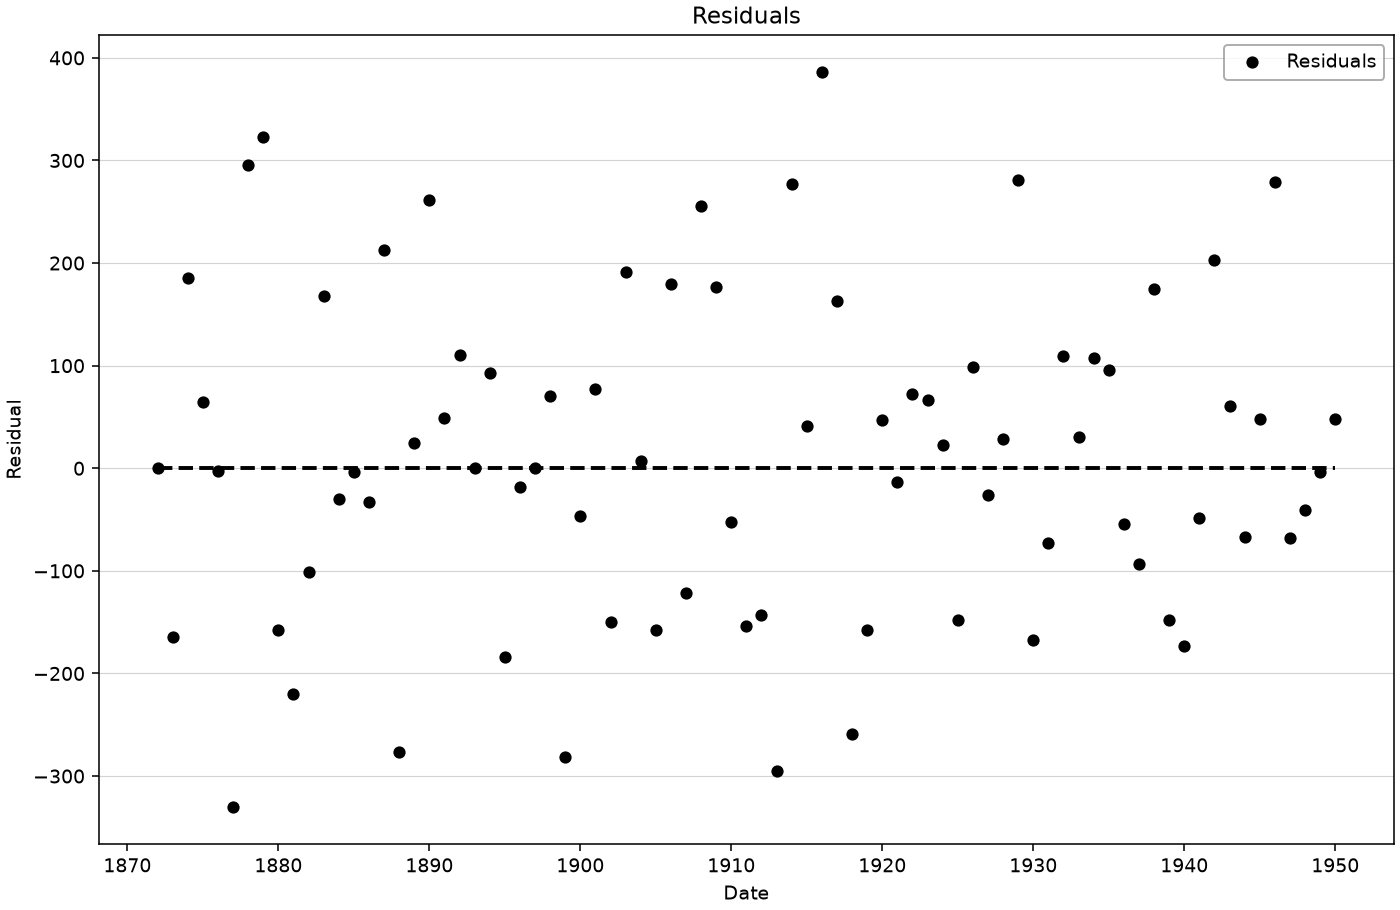

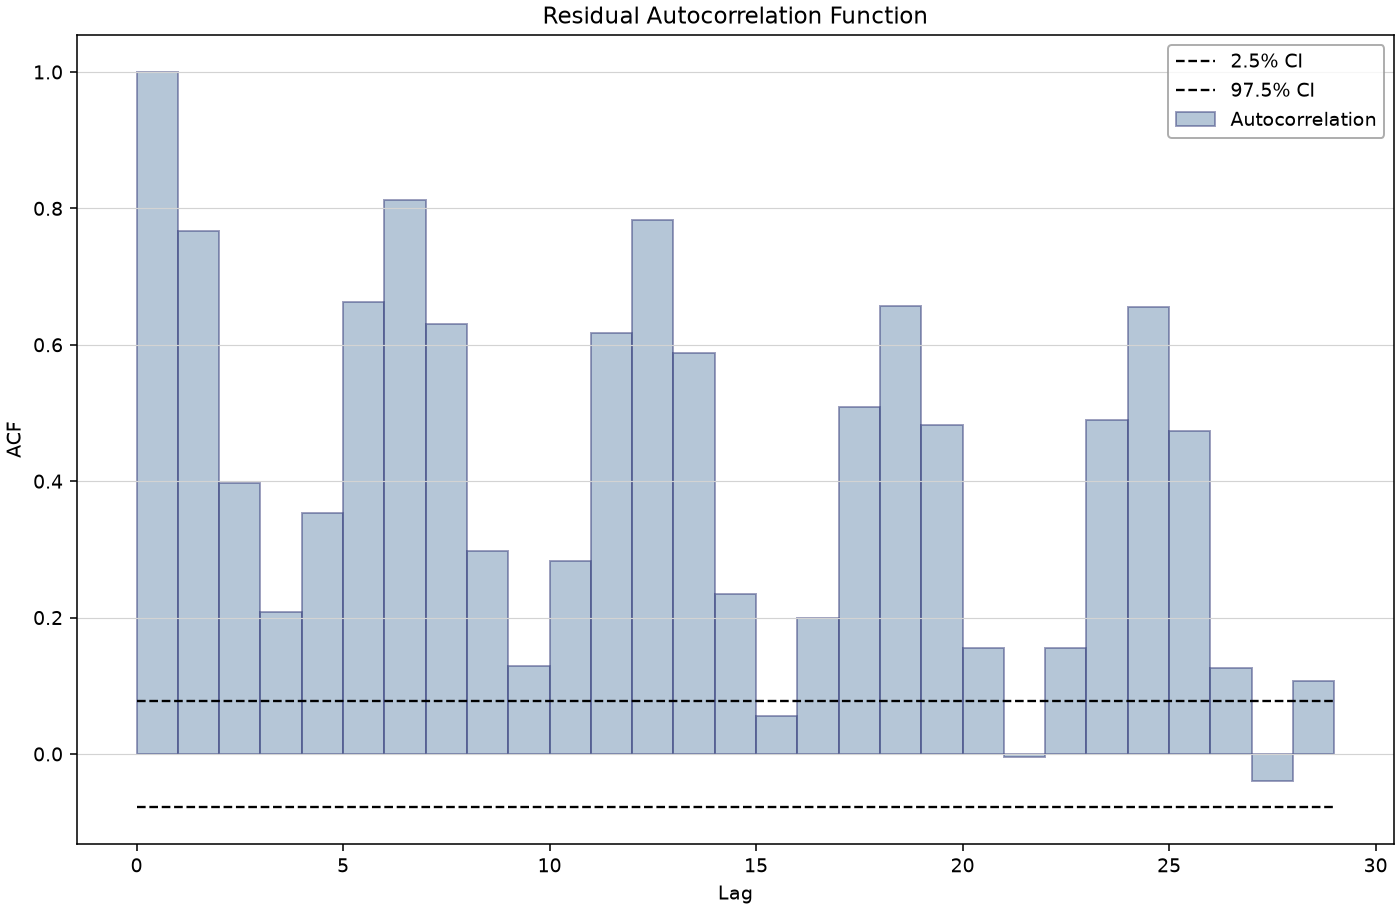

In [8]:
from copy import deepcopy
def nile_display_dates(spec):
    corrected = deepcopy(spec)
    for item in corrected.get("series", []):
        if "x" in item:
            item["x"] = [(pd.Timestamp(date) - pd.DateOffset(years=26)).isoformat()
                         for date in item["x"]]
    corrected["dateCorrection"] = {"years": -26, "scope": "display only",
                                   "reference": "data/references/nile-river-flow.provenance.json"}
    return corrected

figures = {}
for name, analysis in analyses.items():
    series_name = cases[name]["series"]
    context = plot_context(analysis, models[name], name=name, raw=raw,
                           metadata=raw["series"][series_name]["metadata"])
    figures[name] = plots(context)
    if name == "Nile River Flows - TSA":
        for kind in ("series", "residuals"):
            if kind in figures[name]:
                figures[name][kind] = nile_display_dates(figures[name][kind])
    print(name)
    show(figures[name]["series"])
show(figures["Airline Passengers - TSA"]["residual_acf"])
show(figures["Nile River Flows - TSA"]["residuals"])
show(figures["Mauna Loa - CO2"]["residual_acf"])

**Adapt this example:** replace the observations and dates, then choose a model structure and
training split before estimating. Keep a physical interpretation separate from numerical completion.